In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv('Weekly.csv')

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB


In [3]:
data.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


(a)

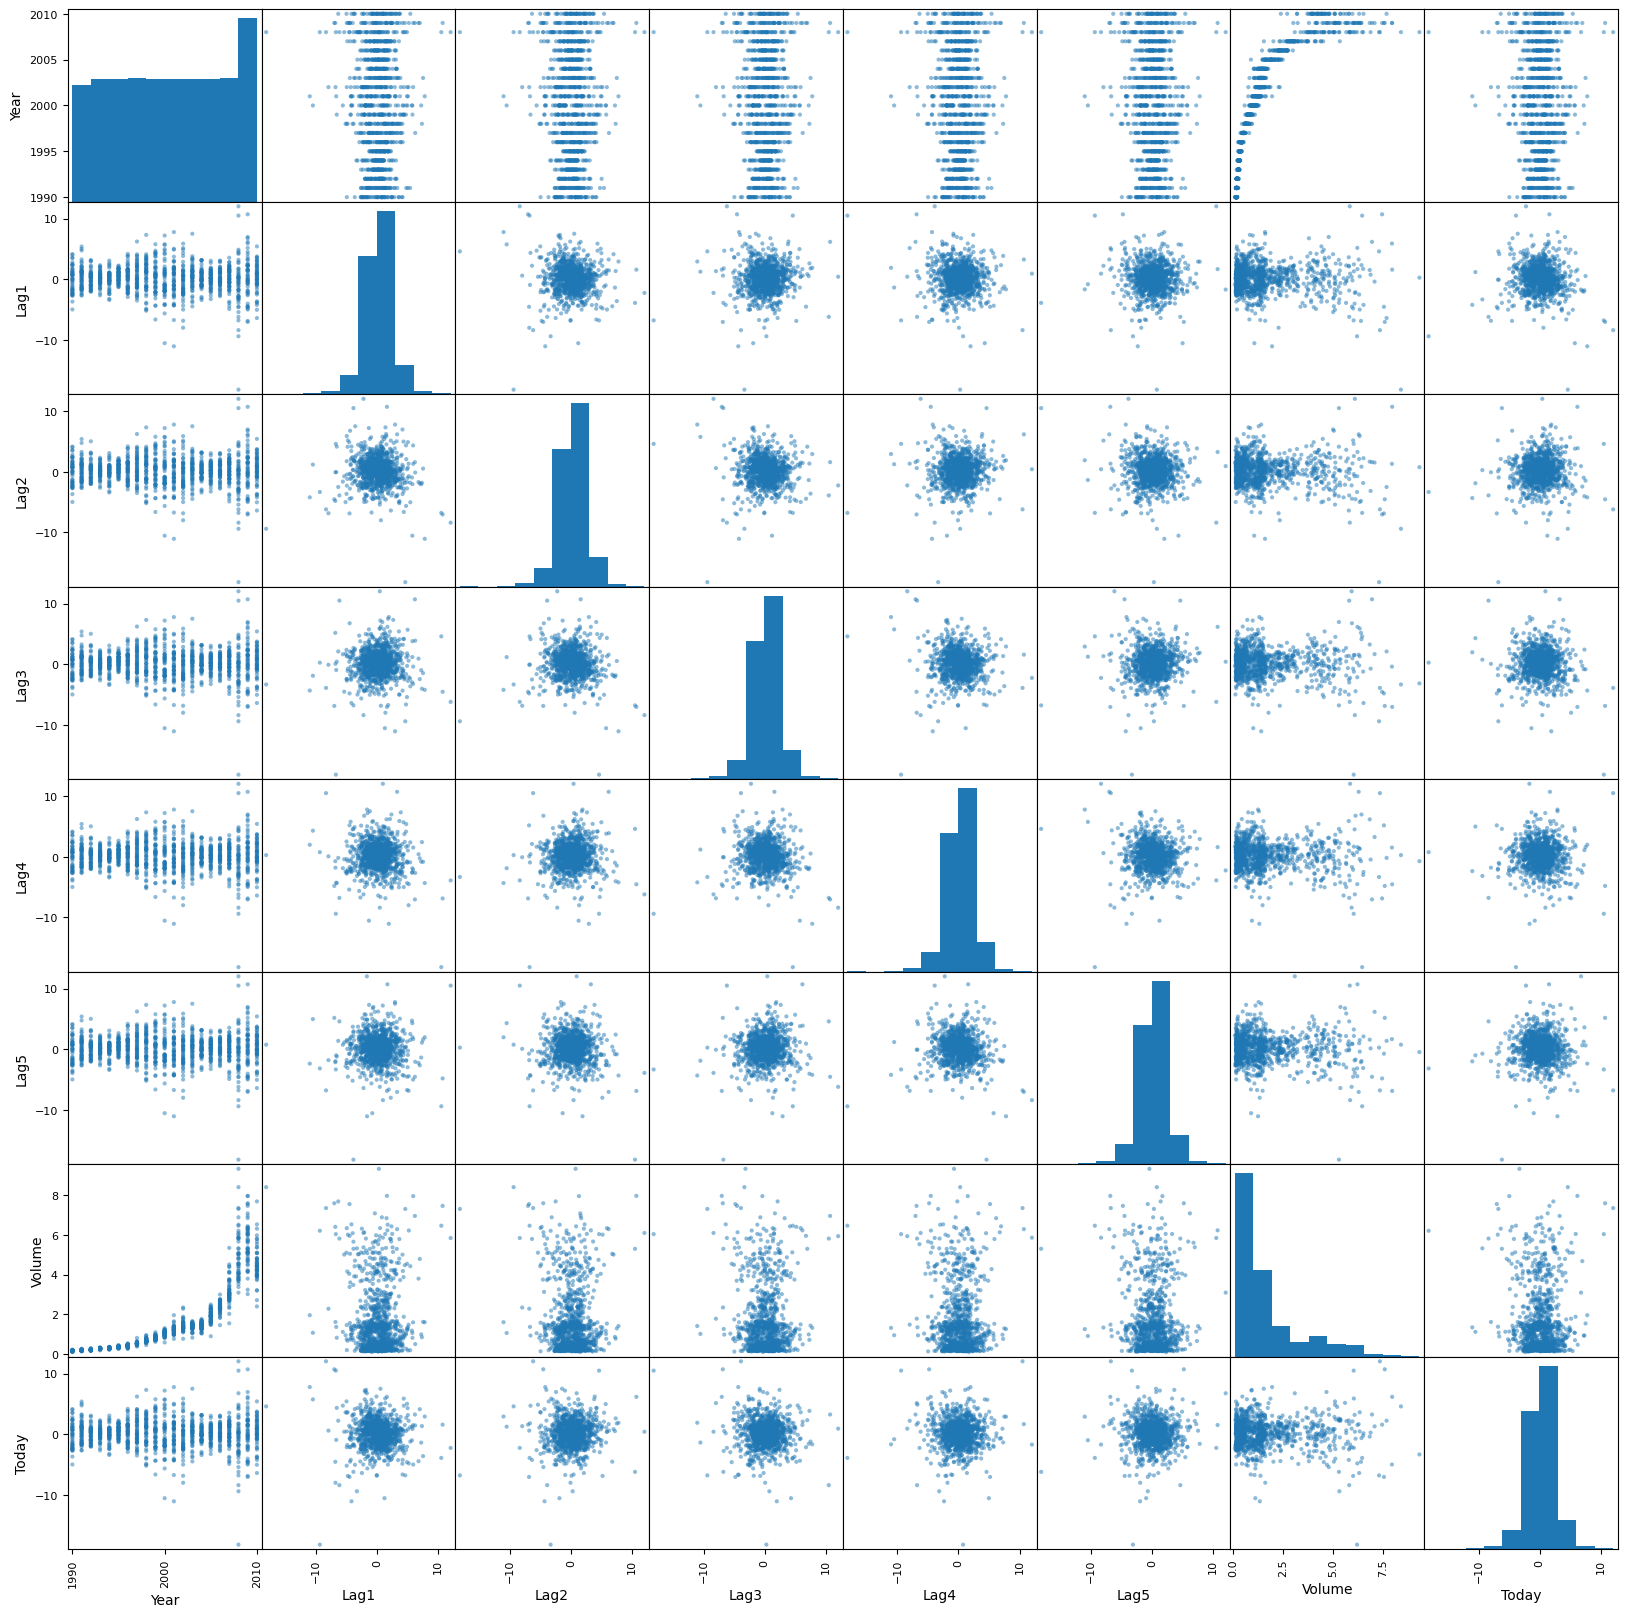

In [4]:
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(data, figsize=(20, 20))
plt.show()

(b)

In [5]:
import statsmodels.api as sm

data['Direction'] = (data['Direction'] == 'Up').astype(int)

X = sm.add_constant(data[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']])
y = data['Direction']

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sat, 08 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        23:43:23   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

(c)

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pred_prob = model.predict(X)
y_pred = np.where(pred_prob > 0.5, 1, 0)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1score = f1_score(y, y_pred)

print("Confusion Matrix:\n", cm)
print(f"\nAccuracy: {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"f1score: {f1score:.3f}")

Confusion Matrix:
 [[ 54 430]
 [ 48 557]]

Accuracy: 0.561
Precision: 0.564
Recall: 0.921
f1score: 0.700


(d)

In [7]:
train = data[data['Year'] <= 2008]
test = data[data['Year'] > 2008]

X_train = sm.add_constant(train['Lag2'])
y_train = train['Direction']

X_test = sm.add_constant(test['Lag2'])
y_test = test['Direction']

model = sm.Logit(y_train, X_train).fit()
print(model.summary())

pred_prob = model.predict(X_test)
y_pred = np.where(pred_prob > 0.5, 1, 0)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print(f"\nAccuracy: {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"f1score: {f1score:.3f}")

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Sat, 08 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        23:43:32   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.

(e)

In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
train = data[data['Year'] <= 2008]
test  = data[data['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']
X_test = test[['Lag2']]
y_test = test['Direction']

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc_LDA = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print(f"\nAccuracy: {acc_LDA:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"f1score: {f1score:.3f}")


Confusion Matrix:
 [[ 9 34]
 [ 5 56]]

Accuracy: 0.625
Precision: 0.622
Recall: 0.918
f1score: 0.742


(f)

In [16]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred = qda.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc_QDA = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print(f"\nAccuracy: {acc_QDA:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"f1score: {f1score:.3f}")


Confusion Matrix:
 [[ 0 43]
 [ 0 61]]

Accuracy: 0.587
Precision: 0.587
Recall: 1.000
f1score: 0.739


(g)

In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc_KNN = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print(f"\nAccuracy: {acc_KNN:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"f1score: {f1score:.3f}")


Confusion Matrix:
 [[22 21]
 [31 30]]

Accuracy: 0.500
Precision: 0.588
Recall: 0.492
f1score: 0.536


(h)

In [18]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc_NB = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print(f"\nAccuracy: {acc_NB:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"f1score: {f1score:.3f}")


Confusion Matrix:
 [[ 0 43]
 [ 0 61]]

Accuracy: 0.587
Precision: 0.587
Recall: 1.000
f1score: 0.739


(i)

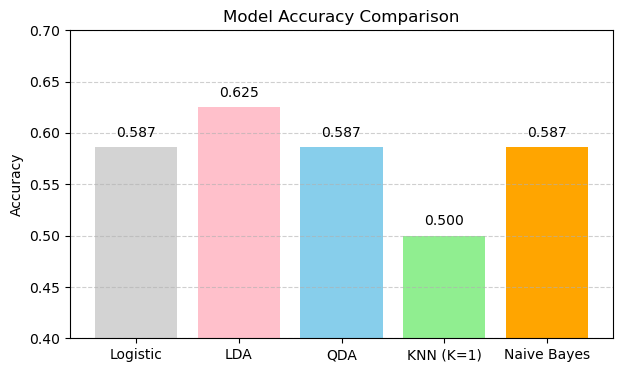

Logistic Regression: 0.587
LDA: 0.625
QDA: 0.587
KNN (K=1): 0.500
Naive Bayes: 0.587


In [26]:
import matplotlib.pyplot as plt

accuracy_dict = {
    'Logistic': acc,          
    'LDA': acc_LDA,            
    'QDA': acc_QDA,
    'KNN (K=1)': acc_KNN,
    'Naive Bayes': acc_NB
}

plt.figure(figsize=(7,4))
plt.bar(accuracy_dict.keys(), accuracy_dict.values(), color=['lightgray','pink','skyblue','lightgreen','orange'])
plt.ylim(0.4, 0.7)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, (model, acc_val) in enumerate(accuracy_dict.items()):
    plt.text(i, acc_val + 0.01, f"{acc_val:.3f}", ha='center', fontsize=10)

plt.show()

print(f"Logistic Regression: {acc:.3f}")
print(f"LDA: {acc_LDA:.3f}")      
print(f"QDA: {acc_QDA:.3f}")
print(f"KNN (K=1): {acc_KNN:.3f}")
print(f"Naive Bayes: {acc_NB:.3f}")

(j)

In [28]:
results = {}

# ---------- 1. Logistic Regression (Lag1, Lag2, Lag1*Lag2, Lag2^2) ----------
train_log = train.copy()
test_log = test.copy()
train_log['Lag1_Lag2'] = train_log['Lag1'] * train_log['Lag2']
train_log['Lag2_sq'] = train_log['Lag2'] ** 2
test_log['Lag1_Lag2'] = test_log['Lag1'] * test_log['Lag2']
test_log['Lag2_sq'] = test_log['Lag2'] ** 2

X_train = sm.add_constant(train_log[['Lag1', 'Lag2', 'Lag1_Lag2', 'Lag2_sq']])
X_test = sm.add_constant(test_log[['Lag1', 'Lag2', 'Lag1_Lag2', 'Lag2_sq']])

logit_model = sm.Logit(y_train, X_train).fit(method='lbfgs', maxiter=500, disp=False)
pred_prob = logit_model.predict(X_test)
y_pred = (pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
results['Logistic(Lag1,Lag2,int,quad)'] = (acc, cm)

# ---------- 2. LDA (Lag1-Lag5, Volume) ----------
lda = LinearDiscriminantAnalysis()
X_train_lda = train[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X_test_lda = test[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
lda.fit(X_train_lda, y_train)
y_pred = lda.predict(X_test_lda)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
results['LDA(Lag1-5,Vol)'] = (acc, cm)

# ---------- 3. QDA (Lag1-Lag5, Volume) ----------
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_lda, y_train)
y_pred = qda.predict(X_test_lda)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
results['QDA(Lag1-5,Vol)'] = (acc, cm)

# ---------- 4. KNN：用 Lag2，搜尋最佳 K ----------
best_k = None
best_acc = -1
best_cm = None

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train[['Lag2']], y_train)
    y_pred = knn.predict(test[['Lag2']])
    acc_k = accuracy_score(y_test, y_pred)
    if acc_k > best_acc:
        best_acc = acc_k
        best_k = k
        best_cm = confusion_matrix(y_test, y_pred)

results[f'KNN(Lag2,K={best_k})'] = (best_acc, best_cm)

# ---------- 5. Naive Bayes (Lag1-Lag5, Volume) ----------
nb = GaussianNB()
nb.fit(X_train_lda, y_train)
y_pred = nb.predict(X_test_lda)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
results['NaiveBayes(Lag1-5,Vol)'] = (acc, cm)

# ---------- 總結輸出 ----------
print("=== Model comparison on 2009-2010 test data ===")
best_model = None
best_acc_overall = -1

for name, (acc, cm) in results.items():
    print(f"\n{name}")
    print("Accuracy:", round(acc, 3))
    print("Confusion matrix:")
    print(cm)
    if acc > best_acc_overall:
        best_acc_overall = acc
        best_model = name

print("\nBest model:", best_model)
print("Best accuracy:", round(best_acc_overall, 3))


=== Model comparison on 2009-2010 test data ===

Logistic(Lag1,Lag2,int,quad)
Accuracy: 0.558
Confusion matrix:
[[ 6 37]
 [ 9 52]]

LDA(Lag1-5,Vol)
Accuracy: 0.462
Confusion matrix:
[[31 12]
 [44 17]]

QDA(Lag1-5,Vol)
Accuracy: 0.433
Confusion matrix:
[[33 10]
 [49 12]]

KNN(Lag2,K=20)
Accuracy: 0.596
Confusion matrix:
[[23 20]
 [22 39]]

NaiveBayes(Lag1-5,Vol)
Accuracy: 0.452
Confusion matrix:
[[42  1]
 [56  5]]

Best model: KNN(Lag2,K=20)
Best accuracy: 0.596
